<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

## SPRINT 6: PROYECTO 

La tienda online Ice se dedica a la venta de videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas.
El objetivo de este proyecto es analizar los datos de ventas de 2016 para la tienda online Ice y poder planear una campaña de estrategia para el 2017.

#### 1. Captura de datos

In [1]:
# Cargar todas las librerías

import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
# Carga el archivo de datos en un DataFrame

games=pd.read_csv("/datasets/games.csv")
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#### 2. Preparación de datos

In [3]:
#Reemplaza los nombres de las columnas en minúsculas
games.columns = games.columns.str.lower()

#Convertimos los datos de year de flotante a entero
#Primero debemos tratar los nulos o saldrá error.
games.dropna(subset=['year_of_release'], inplace=True)

games['year_of_release'] = games['year_of_release'].astype(int)

#games.tail(10)
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.5+ MB


Para trasnformar el tipo de dato del año de lanzamiento de flotante a entero es importante tratar los datos nulos. En este caso, se ha decidio eliminarlos a fin de tener datos más "limpios" para análisis y considerando que sólo representan el 1.6% del dataset (269 juegos).

Para las últimas 3 columnas tenemos muchos valores ausentes.
+ critic_score: 52% de datos faltantes
+ user_score:   41% de datos faltantes  
+ rating:       42% de datos faltantes 

Iniciaremos tratando las columnas de user_score, que además tiene un tipo de dato incorrecto (object en lugar de float64).

In [4]:
# Revisar valores únicos en user_score
print(games['user_score'].value_counts())

# Buscar valores problemáticos
print(games['user_score'].unique())
print(games['critic_score'].unique())
print(games['rating'].unique())

tbd    2376
7.8     322
8       285
8.2     276
8.3     252
       ... 
1.9       2
0.9       2
9.6       2
0         1
9.7       1
Name: user_score, Length: 96, dtype: int64
['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']
[76. nan 82. 80. 89. 58. 87. 91. 61. 97. 95. 77. 88. 83. 94. 93. 85. 86.
 98. 96. 90. 84. 73. 74. 78. 92. 71. 72. 68. 62. 49. 67. 81. 66. 56. 79.
 70. 59. 64. 75. 60. 63. 69. 50. 25. 42. 44. 55. 48. 57. 29. 47. 65. 54.
 20. 53. 37. 38. 33. 52. 30. 32. 43. 

Análizando los resultados anteriores, podemos concluir que los datos que están generando complicaciones en el tipo de dato de "user_score" son los valores nulos y los "tbd" o "to be determined". Dado la gran proporción que estos datos representan, eliminarlos reducirá mucho nuestra base de datos, por lo que no serán eliminados. En su lugar, remplazaremos los tbd con valores nulos para corregir el tipo y poder sacar métricas numéricas.

In [5]:
# Limpiar unos de los valores problemáticos "tbd" remplazandolos por NaN
games['user_score'] = games['user_score'].replace('tbd', np.nan)

# Convertir a numérico:
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

games.info()

#Analizamos si existe alguna coincidencia entre los valores con scores faltantes
userscore_nan = games[games["user_score"].isna()]

userscore_nan["genre"].unique()
userscore_nan["platform"].unique()
userscore_nan["year_of_release"].unique()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


array([1985, 1996, 1989, 1984, 2005, 1999, 1990, 2006, 1988, 2002, 2010,
       1998, 2015, 2013, 2009, 2014, 1992, 1993, 2004, 1994, 1997, 2012,
       2007, 1982, 2016, 2003, 2011, 1986, 2000, 2001, 1995, 2008, 1991,
       1981, 1987, 1980, 1983])

Analizando los años, la plataforma y el genero no podemos concluir que los valores nulos sólo pertenecen a un mismo grupo. 

In [6]:
#Calculamos las ventas total es de cada juego 

games["total_sales"]=games["na_sales"]+games["eu_sales"]+games["jp_sales"]+games["other_sales"]
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


#### 3. Análisis de datos

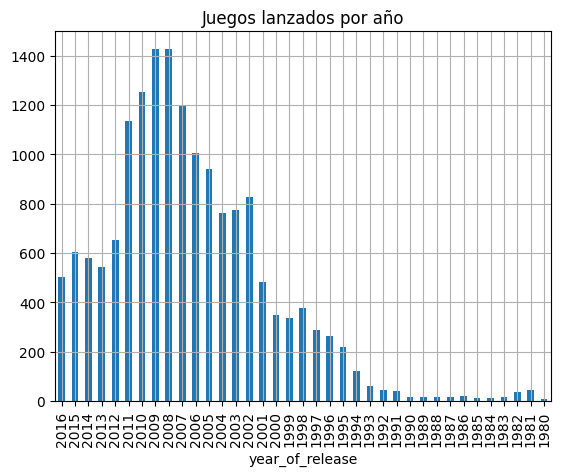

In [7]:
#Analizamos el número de juegos lanzados por año
games_per_year = games.groupby("year_of_release").size()
games_per_year=games_per_year.sort_index(ascending=False)


games_per_year.plot(title="Juegos lanzados por año",kind="bar",grid=True)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de presentar los datos, podemos ver claramente la tendencia de los videojuegos con un incremento constante en años anteriores que ha empezado a ir en declive en los últimos años
</div>


Observando los juegos liberados por año podemos notar que de 1980 a 1994 el número de juegos lanzado era inferior a 200, lo que implica que los datos de estos 14 años no son muy significativos en volumen. Posteriormente, obsevamos los máximos valores de lanzamientos en 2008 y 2009, superando los 1400 juegos lanzados.

In [8]:
#Ventas por plataforma 

sales_per_platform = games.groupby("platform")["total_sales"].sum()
sales_per_platform = sales_per_platform.sort_values(ascending=False) 

#Top 10 plataformas con mayores ventas
top10_platforms=sales_per_platform.head(10)
top10_platforms

platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

                    PS2    X360     PS3     Wii      DS     PS  PS4    GBA  \
year_of_release                                                              
2000              39.17     NaN     NaN     NaN     NaN  96.37  NaN   0.07   
2001             166.43     NaN     NaN     NaN     NaN  35.59  NaN  61.53   
2002             205.38     NaN     NaN     NaN     NaN   6.67  NaN  74.16   
2003             184.31     NaN     NaN     NaN     NaN   2.07  NaN  56.67   
2004             211.81     NaN     NaN     NaN   17.27    NaN  NaN  77.91   
2005             160.66    8.25     NaN     NaN  130.14    NaN  NaN  33.86   
2006             103.42   51.62   20.96  137.15  119.81    NaN  NaN   5.28   
2007              75.99   95.41   73.19  152.77  146.94    NaN  NaN   3.40   
2008              53.90  135.26  118.52  171.32  145.31    NaN  NaN    NaN   
2009              26.40  120.29  130.93  206.97  119.54    NaN  NaN    NaN   
2010               5.64  170.03  142.17  127.95   85.02    NaN  

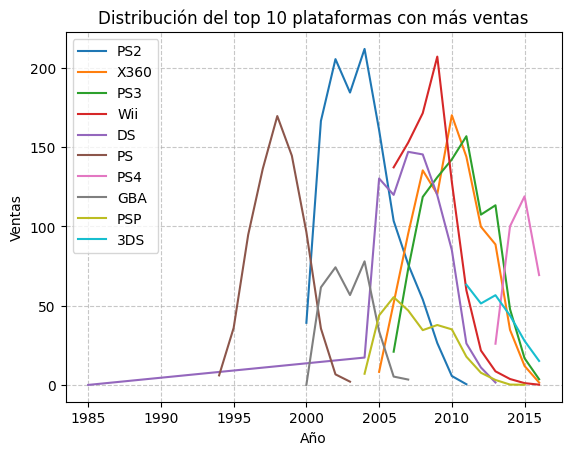

In [9]:
# Para cada plataforma del top, ver ventas por año

all_platforms_sales = pd.DataFrame()

for platform in top10_platforms.index:
    platform_data = games[games['platform'] == platform]
    yearly_sales = platform_data.groupby('year_of_release')['total_sales'].sum()
    yearly_sales.plot(label=platform) # Crear gráfico de línea o barras
    all_platforms_sales[platform] = yearly_sales #Crear una tabla para comparar los datos


print(all_platforms_sales)


plt.title("Distribución del top 10 plataformas con más ventas")
plt.ylabel("Ventas")
plt.xlabel("Año")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Buena manera de mostrar los datos, gracias a la gráfica podemos observar el tiempo de vida de cada una de las plataformas

Recomiendo filtrar los datos de los primeros años, como se puede apreciar en la gráfica son poco relevantes
</div>


En la gráfica anterior podemos notar que todos las plataformas anteriores a 2005 ya no tienen ventas para 2015, con lo que podemos generalizar que todos las plataformas creadas previo a esa fecha ya no son vigentes en el mercado y por lo tanto es valido removerlas de nuestra base de datos pues tampoco estarán vigentes para el año de proyección (2017). Asumiremos una vida total promedio en el mercado de 10 años. Además, los videojuegos alcanzan su pico de ventas en un máximo de 6 años después de la creacion de la plataforma nueva (en promedio), por lo que para nuestro analisis usaremos datos a partir de 2011, asumiendo que el juego mas antiguo que puede alcanzar su pico en 2017 fue lanzado no antes de 2011 y todos los videojuegos lanzados anterior a esta fecha ya estan en declive de demanda.

In [10]:
#Aplicamos un filtro a nuestra base de datos 

active_games = games[games["year_of_release"]>2010]
sales_per_platform = active_games.pivot_table(index="platform",columns="year_of_release",values="total_sales",aggfunc="sum",margins=True)
sales_per_platform = sales_per_platform.sort_values(by="All",ascending=False)
sales_per_platform

year_of_release,2011,2012,2013,2014,2015,2016,All
platform,,,,,,,
All,507.58,355.84,361.24,331.53,267.98,129.94,1954.11
PS3,156.78,107.36,113.25,47.76,16.82,3.60,445.57
X360,143.84,99.74,88.58,34.74,11.96,1.52,380.38
PS4,NaN,NaN,25.99,100.00,118.90,69.25,314.14
3DS,63.20,51.36,56.57,43.76,27.78,15.14,257.81
XOne,NaN,NaN,18.96,54.07,60.14,26.15,159.32
PC,35.03,23.22,12.38,13.28,8.52,5.25,97.68
Wii,59.65,21.71,8.59,3.75,1.14,0.18,95.02
WiiU,NaN,17.56,21.65,22.03,16.35,4.60,82.19


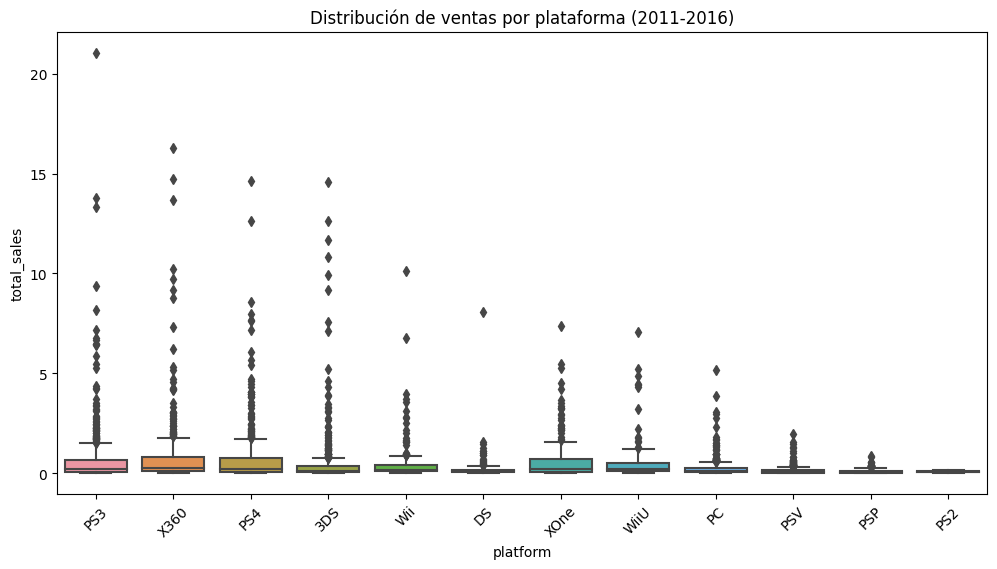

In [11]:
#Creamos un diagrama de caja de las ventas totales

# Boxplot de ventas totales por plataforma (datos filtrados)
plt.figure(figsize=(12, 6))
sns.boxplot(data=active_games, x='platform', y='total_sales')
plt.xticks(rotation=45)
plt.title("Distribución de ventas por plataforma (2011-2016)")
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

En la gráfica podemos ver muchos valores atipicos que impiden que las cajas se muestren correctamente, por lo que recomiendo usar el parametro `showfliers = False`, de esta manera se remueven estos valores de la gráfica, te dejo el ejemplo en la celda de abajo
</div>


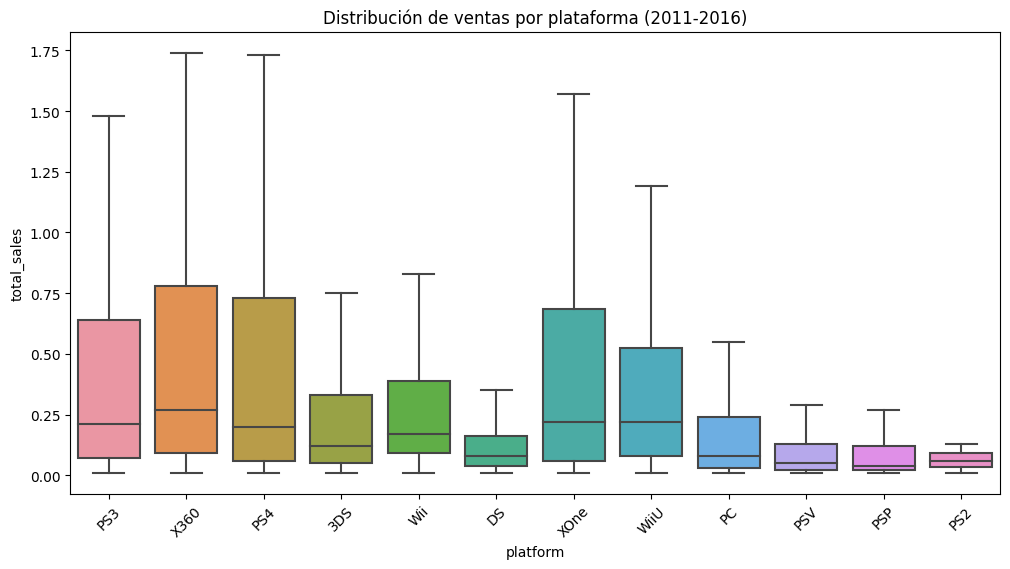

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=active_games, x='platform', y='total_sales', showfliers = False)
plt.xticks(rotation=45)
plt.title("Distribución de ventas por plataforma (2011-2016)")
plt.show()

En el gráfico de caja podemos observar que las ventas promedio son bajas para todas las plataformas y son pocos los juegos que generan una ganacia alta (valores atípicos). Se puede asumir que estos juegos son los que crecen exponencialmente las ventas totales de la plataforma y los que intentamos predecir.

##### Analisis de correlación entre los scores y las ventas


El coeficiente de correlación entre las reseñas de los usuarios y las ventas es:-0.031957110204556376
El coeficiente de correlación entre las reseñas de los criticos y las ventas es:0.40656790206178095


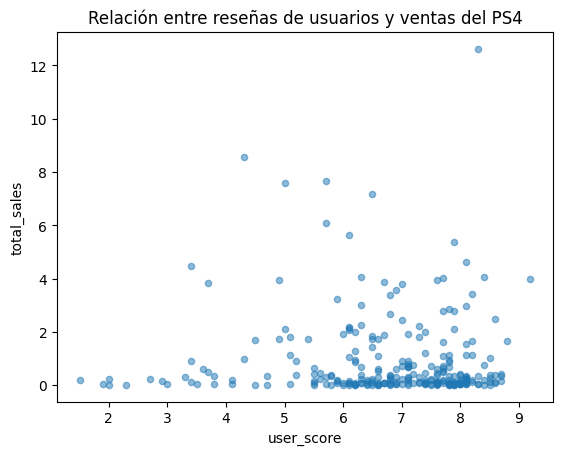

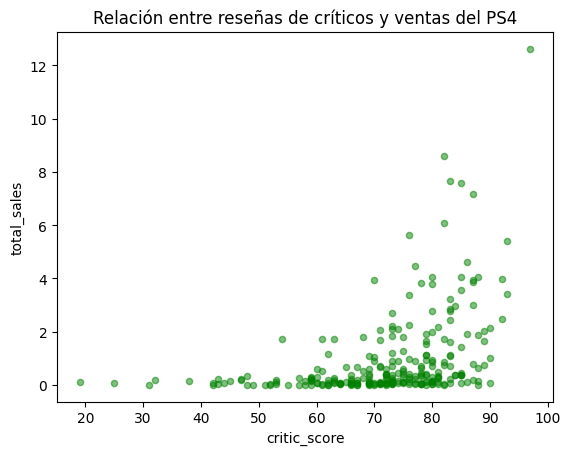

In [13]:
#Elegimos el PSP4 para nuestro análisis 

#Correlación vs el user score

platform_selected = active_games[active_games["platform"]=="PS4"]
platform_selected.plot(title="Relación entre reseñas de usuarios y ventas del PS4",y="total_sales",x="user_score",kind="scatter", alpha=0.5)

coef_corr_1= platform_selected["user_score"].corr(platform_selected["total_sales"])
print(f"El coeficiente de correlación entre las reseñas de los usuarios y las ventas es:{coef_corr_1}")

#Correlacion vs el critic score
platform_selected.plot(title="Relación entre reseñas de críticos y ventas del PS4",y="total_sales",x="critic_score",kind="scatter", alpha=0.5, color="green")

coef_corr_2= platform_selected["critic_score"].corr(platform_selected["total_sales"])
print(f"El coeficiente de correlación entre las reseñas de los criticos y las ventas es:{coef_corr_2}")


El coeficiente de correlación de las reseñas de los usuarios y las ventas es negativo, lo cual significa que conforme el score otorgado es más alto, las ventas bajan.
Por el contrario, el coeficiente de correlación de las reseñas de los críticos y las ventas es positivo, lo que significa que conforme el score otorgado es más alto, las ventas también aumentan.

Ambos scores (tanto el de los críticos como el de los usuarios) tienen relativamente el mismo impacto en el mercado, aunque en distintas direcciones.

Es importante considerar que el dominio de los scores es distinto en cada gráfica, por eso decimos que son casi iguales los coeficientes de correlación aunque uno se -0.03 y otro 0.4.
Dicho lo anterior, podríamos plantear como hipótesis que los juegos con más venta son también son los mejores calificados en el mercado por los críticos.

Veremos que sucede si probamos en otra plataforma.

El coeficiente de correlación entre las reseñas de los usuarios y las ventas es:-0.06892505328279414
El coeficiente de correlación entre las reseñas de los criticos y las ventas es:0.4169983280084017


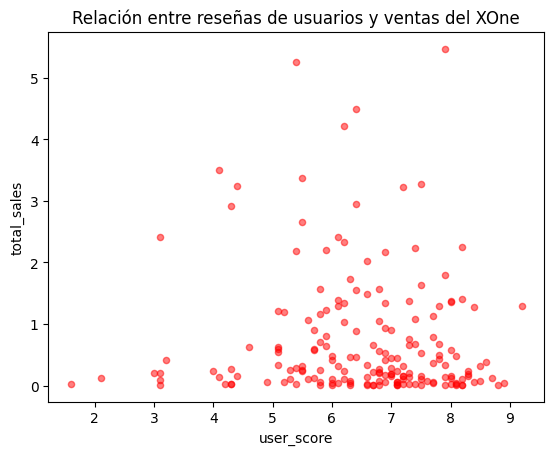

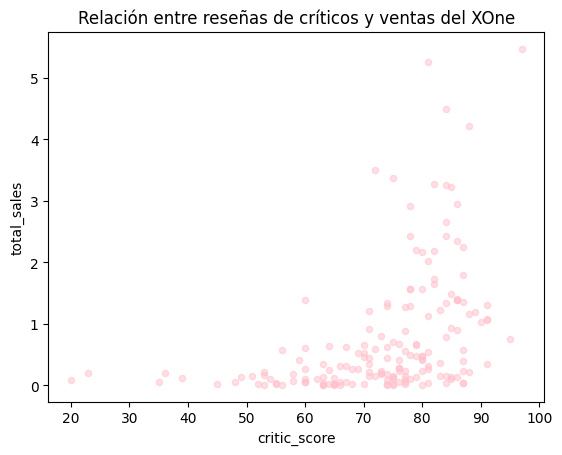

In [14]:
#Elegimos el XOne para nuestro análisis 

#Correlación vs el user score

platform_selected = active_games[active_games["platform"]=="XOne"]
platform_selected.plot(title="Relación entre reseñas de usuarios y ventas del XOne",y="total_sales",x="user_score",kind="scatter", alpha=0.5, color="red")

coef_corr_1= platform_selected["user_score"].corr(platform_selected["total_sales"])
print(f"El coeficiente de correlación entre las reseñas de los usuarios y las ventas es:{coef_corr_1}")

#Correlacion vs el critic score
platform_selected.plot(title="Relación entre reseñas de críticos y ventas del XOne",y="total_sales",x="critic_score",kind="scatter", alpha=0.5, color="pink")

coef_corr_2= platform_selected["critic_score"].corr(platform_selected["total_sales"])
print(f"El coeficiente de correlación entre las reseñas de los criticos y las ventas es:{coef_corr_2}")


El coeficiente de correlación entre las reseñas de los usuarios y las ventas es:0.14550376734945006
El coeficiente de correlación entre las reseñas de los criticos y las ventas es:0.2922694954272934


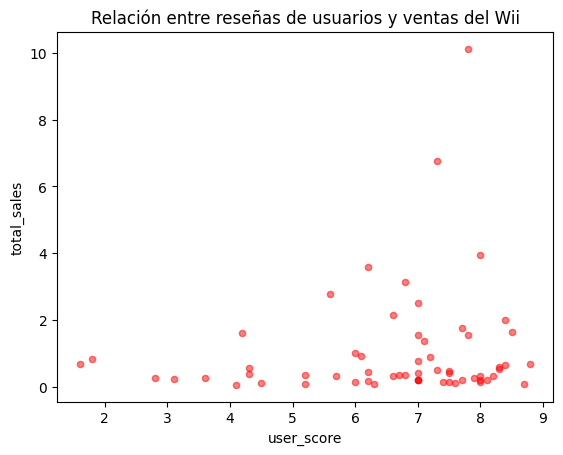

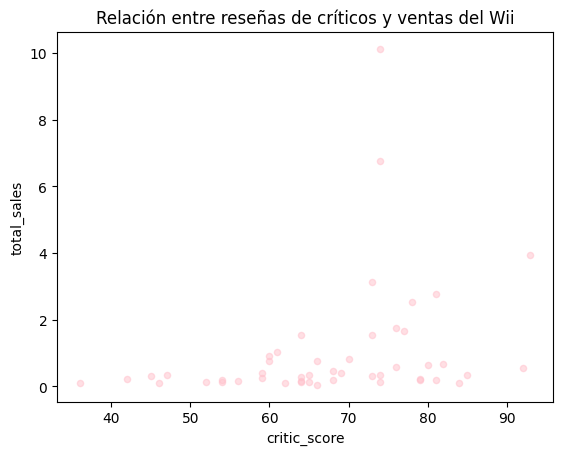

In [15]:
#Elegimos el Wii para nuestro análisis 

#Correlación vs el user score

platform_selected = active_games[active_games["platform"]=="Wii"]
platform_selected.plot(title="Relación entre reseñas de usuarios y ventas del Wii",y="total_sales",x="user_score",kind="scatter", alpha=0.5, color="red")

coef_corr_1= platform_selected["user_score"].corr(platform_selected["total_sales"])
print(f"El coeficiente de correlación entre las reseñas de los usuarios y las ventas es:{coef_corr_1}")

#Correlacion vs el critic score
platform_selected.plot(title="Relación entre reseñas de críticos y ventas del Wii",y="total_sales",x="critic_score",kind="scatter", alpha=0.5, color="pink")

coef_corr_2= platform_selected["critic_score"].corr(platform_selected["total_sales"])
print(f"El coeficiente de correlación entre las reseñas de los criticos y las ventas es:{coef_corr_2}")


Los coeficientes de correlacion de la plataforma XOne si cumplen nuestra hipotesis inicial, sin embargo, al probar con Wii ya no es correcto, pues ambos coeficientes muestras una correlación positiva.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de mostrar la correlación entre las ventas y las reseñas, como bien mencionas la correlación no es siempre positiva, por lo que no siempre las buenas reseñas van a implicar un gran número de ventas
</div>


#### Distribución de los juegos por género 

In [16]:

sales_per_genre = active_games.pivot_table(index="genre",values="total_sales",aggfunc="sum")
sales_per_genre["number_of_games"] = active_games.groupby(["genre"])["name"].count()
sales_per_genre["sales_per_game"]= sales_per_genre["total_sales"]/sales_per_genre["number_of_games"]
sales_per_genre = sales_per_genre.sort_values(by= "sales_per_game",ascending=False)
sales_per_genre

,total_sales,number_of_games,sales_per_game
genre,,,
Shooter,402.91,329,1.224650
Platform,88.68,122,0.726885
Sports,237.15,389,0.609640
Role-Playing,245.63,465,0.528237
Racing,88.31,180,0.490611
Action,557.80,1269,0.439559
Fighting,66.90,159,0.420755
Misc,139.42,375,0.371787
Simulation,50.26,136,0.369559


Podemos conlcuir que los juegos de género de acción son los que tienen más ventas totales y los del género Puzzle son los que reunen menos ganancias.
Sin embargo, considerando la ganancia promedio por juego, la distribución cambia, siendo los del genero shooter los que reunen más ganancias por juego. 


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Buena manera de presentar los datos, podemos ver claramente cuales son los géneros preferidos de las personas, las observaciones que haces me parecen buenas también
</div>


#### 4. Creación de perfil de usuario por región 

In [17]:
#Plataformas principales por región 


sales_per_platform_per_year = active_games.pivot_table(index = "platform",columns="year_of_release",values="total_sales",aggfunc=sum)
sales_per_platform = active_games.pivot_table(index = "platform",values=["na_sales","eu_sales","jp_sales"],aggfunc=sum)

# NA
top5_platforms_na = sales_per_platform.sort_values(by="na_sales",ascending=False).head(5)
top5_platforms_na = top5_platforms_na["na_sales"]

#EU
top5_platforms_eu = sales_per_platform.sort_values(by="eu_sales",ascending=False).head(5)
top5_platforms_eu = top5_platforms_eu["eu_sales"]

#JP 
top5_platforms_jp = sales_per_platform.sort_values(by="jp_sales",ascending=False).head(5)
top5_platforms_jp = top5_platforms_jp["jp_sales"]


print(f"Las plataformas con más ventas en Norteamérica son: \n {top5_platforms_na}")
print(f"Las plataformas con más ventas en Europa son: \n {top5_platforms_eu}")
print(f"Las plataformas con más ventas en Japón son: \n {top5_platforms_jp} \n")

sales_per_platform_per_year


Las plataformas con más ventas en Norteamérica son: 
 platform
X360    226.80
PS3     168.26
PS4     108.74
XOne     93.12
3DS      82.65
Name: na_sales, dtype: float64
Las plataformas con más ventas en Europa son: 
 platform
PS3     163.10
PS4     141.09
X360    117.10
3DS      61.27
PC       56.70
Name: eu_sales, dtype: float64
Las plataformas con más ventas en Japón son: 
 platform
3DS    100.62
PS3     49.39
PSP     24.04
PSV     21.84
PS4     15.96
Name: jp_sales, dtype: float64 



year_of_release,2011,2012,2013,2014,2015,2016
platform,,,,,,
3DS,63.20,51.36,56.57,43.76,27.78,15.14
DS,26.18,11.01,1.54,NaN,NaN,NaN
PC,35.03,23.22,12.38,13.28,8.52,5.25
PS2,0.45,NaN,NaN,NaN,NaN,NaN
PS3,156.78,107.36,113.25,47.76,16.82,3.60
PS4,NaN,NaN,25.99,100.00,118.90,69.25
PSP,17.82,7.69,3.14,0.24,0.12,NaN
PSV,4.63,16.19,10.59,11.90,6.25,4.25
Wii,59.65,21.71,8.59,3.75,1.14,0.18


In [18]:
#Géneros principales por región 

sales_per_genre = active_games.pivot_table(index = "genre",values=["na_sales","eu_sales","jp_sales"],aggfunc=sum)

# NA
top5_genres_na = sales_per_genre.sort_values(by="na_sales",ascending=False).head(5)
top5_genres_na = top5_genres_na["na_sales"]

#EU
top5_genres_eu = sales_per_genre.sort_values(by="eu_sales",ascending=False).head(5)
top5_genres_eu = top5_genres_eu["eu_sales"]

#JP 
top5_genres_jp = sales_per_genre.sort_values(by="jp_sales",ascending=False).head(5)
top5_genres_jp = top5_genres_jp["jp_sales"]


print(f" \n Los géneros con más ventas en Norteamérica son: \n {top5_genres_na}")
print(f"Los géneros con más ventas en Europa son: \n {top5_genres_eu}")
print(f"Los géneros con más ventas en Japón son: \n {top5_genres_jp}")

 
 Los géneros con más ventas en Norteamérica son: 
 genre
Action          230.92
Shooter         194.43
Sports          108.70
Role-Playing     83.78
Misc             69.69
Name: na_sales, dtype: float64
Los géneros con más ventas en Europa son: 
 genre
Action          199.12
Shooter         148.02
Sports           88.48
Role-Playing     62.30
Racing           40.58
Name: eu_sales, dtype: float64
Los géneros con más ventas en Japón son: 
 genre
Role-Playing    79.87
Action          63.62
Misc            17.60
Fighting        12.38
Platform        12.13
Name: jp_sales, dtype: float64


Action, Shooter y sports encabezan la lista de géneros con más ventas tanto en Europa como en Norteamérica, sin embargo, la distribución cambia totalmente al centrarnos en Japón, pues el top 2 y 3 ni siquiera forman parte de la lista de géneros principales de la región. Esto nos sugiere que las preferencias del mercado en Japón se comportan de manera distinta al resto de la población evaluada.

In [19]:
#Análisis de ventas por región según su clasificación 

esrb_sales = active_games.groupby(['rating'])[['na_sales', 'eu_sales', 'jp_sales']].sum()
esrb_sales

,na_sales,eu_sales,jp_sales
rating,,,
E,170.17,141.73,36.68
E10+,117.72,78.00,11.23
EC,0.42,0.00,0.00
M,308.45,250.26,26.14
RP,0.00,0.03,0.00
T,109.31,83.16,33.39


Los juegos M "Mature" venden 11 veces más en Norteamérica que en Japón. Esta es la categoria más vendida tanto en Europa como en Norteamerica, mientras que en Japón la categoria mas vendida es la E "Everyone."

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Los resultados mostrados en los últimos ejercicios me parecen correctos, sin embargo recomiendo acompañar estos rsultados con gráficas que resalten las diferencias entre las regiones
</div>


#### 5. Pruebas de hipótesis 

In [20]:
# Prueba de hipotesis entre 2 plataformas
# Definimos la hipotesis nula
# h_0 = Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

scores_xone = active_games[active_games["platform"]=="XOne"]["user_score"].dropna().tolist()
scores_pc = active_games[active_games["platform"]=="PC"]["user_score"].dropna().tolist()

print("Datos de Xbox One:")
print(f"Cantidad de scores: {len(scores_xone)}")

print("\nDatos de PC:")
print(f"Cantidad de scores: {len(scores_pc)} \n")

# nivel crítico de significación estadística
alpha = 0.05

# prueba la hipótesis de que las medias de las dos poblaciones independientes son iguales
results = st.ttest_ind(scores_xone,scores_pc,equal_var=False)

print('valor p:',results.pvalue)

# comparar los valores p obtenidos con el nivel de significación estadística
if results.pvalue < alpha: 
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Datos de Xbox One:
Cantidad de scores: 182

Datos de PC:
Cantidad de scores: 307 

valor p: 0.6130712247638477
No podemos rechazar la hipótesis nula


El que no podamos rechazar la hipótesis nula significa que no podemos afirmar que hay diferencia entre los promedios de score por plataforma.

In [21]:
# Prueba de hipotesis entre 2 géneros 
# Definimos la hipotesis nula
# h_0 = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

scores_action = active_games[active_games["genre"]=="Action"]["user_score"].dropna().tolist()
scores_sports = active_games[active_games["genre"]=="Sports"]["user_score"].dropna().tolist()

print("Datos del género Action:")
print(f"Cantidad de scores: {len(scores_action)}")

print("\nDatos del género Sports:")
print(f"Cantidad de scores: {len(scores_sports)} \n")

# nivel crítico de significación estadística
alpha = 0.05

# prueba la hipótesis de que las medias de las dos poblaciones independientes son iguales
results = st.ttest_ind(scores_action,scores_sports,equal_var=False)

print('valor p:',results.pvalue)

# comparar los valores p obtenidos con el nivel de significación estadística
if results.pvalue < alpha: 
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Datos del género Action:
Cantidad de scores: 664

Datos del género Sports:
Cantidad de scores: 246 

valor p: 8.285648549432565e-19
Rechazamos la hipótesis nula


Al rechazar la hipótesis estamos afirmando que sí hay diferencia significativa entre los promedios de los scores de los juegos de genero de acción vs deportes.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


### Sobre los datos:
La base de datos con la que trabajamos presenta muchos datos faltantes de scores, lo que reduce la cantidad de datos de manera significativa, en especial para las pruebas estadisticas. Adicional, en la evaluación de datos se descubrio que la vigencia de un juego en el mercado es menor a 10 años, con lo cual se volvió inecesario considerar la información desde el año 2000. Es importante tener en consideración que adicional a los parametros ya estudiados, hay otros factores que influencian el mercado como el prestigio de la marca del videojuego, la fecha de lanzamiento, la campaña de marketing utilizada, por mencionar algunos. 

### Sobre las pruebas estadísticas:
El resultado de nuestra primer prueba de hipotesis nos sugiere que las calificaciones de los usuarios entre plataformas es en promedio, muy parecida, es decir, que la plataforma no influencia la preferencia de los usuarios, por lo tanto la estrategia de marketing puede ser la misma entre plataformas y en su lugar, usar otros factores para decidir. 
Por otro lado, que Action y Sport tuvieran calificaciones promedio estadísticamente distintas, sugiere que el genero si es un factor que influencia la preferencia de los usuarios. 
Además, comparando los coeficientes de correlación de múltiples juegos, no encontramos un patrón o prueba cosistente que las ventas sean definidas de manera significativa por las calificaciones de los usuarios.

### Recomendaciones estratégicas:
De acuerdo a los datos analizados, la mejor estrategia sería en invertir en los juegos con mayor potencial de crecimiento, es decir, las nuevas plataformas, como Xbox One y PS4 que debutaron en 2013.
Por otro lado, al observar las ventas de cada género por región, descubrimos que hay una diferencia de preferencias entre Norteamerica y Europa versus Japón, por lo que es importante ajustar una estrategia considerando esta diferencia. Mientras que para NA y EU el marketing debera concentrarse en los géneros de Action, Shooter y sports, para Japon, la estrategia deberia enfocarse en Role-playing, Action y Misc.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div> 

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Se pueden incluir más graficas para resaltar las observaciones o datos que muestras, especialmente en la parte donde se comparan las distintas regiones del mundo

</div>